In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [27]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [28]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [29]:
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [30]:
Lum = 3000

In [31]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [32]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_14TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_14TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.2474345231655215 [fb]
0.26523144909845914 [fb]


In [33]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.7748869590226768 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.4378741659574781 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.2474345231655215 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.13982063344676618 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.07901003177465696 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.04581708431512623 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.02656884408205899 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.015388910834251649 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.00891339404654277 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.005260680024994185 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.7980588250285466 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.46007640520693416 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.26523144909845914 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.15538479377277226 [fb]
# eventos VLQ 1800 Ge

In [34]:
# # FOR 13 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.19136
# k_tt = 1.2593273872014419
# crossfid_tt = (5.1373984*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.39648 * 3.440676833094312,
#               'singletP2': 0.283008 * 3.440676833094312,
#               'Wbbjets': 0.9988452079186325 * 0.9781509289273502,
#               'ttW': 0.0231785208 * 3.056401327463198,
#               'ttZ': 0.050087088 * 3.056401327463198,
#               'ttH': 0.025004896 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [35]:
# # FOR 13.6 TeV

# k_fakett = 1.1053030485310749
# crossfid_fakett = 0.222944
# k_tt = 1.2593273872014419
# crossfid_tt = (6.70014736*k_tt) + (crossfid_fakett * k_fakett)


# fidxsec_SM = {'tt': crossfid_tt,
#               'singletP1': 0.5381712 * 3.440676833094312,
#               'singletP2': 0.30416544 * 3.440676833094312,
#               'Wbbjets': 1.3920832941861587 * 0.9781509289273502,
#               'ttW': 0.03137058432 * 3.056401327463198,
#               'ttZ': 0.06296147519999999 * 3.056401327463198,
#               'ttH': 0.0317827504 * 2.2127445612386474
#               }

# for ch_it in fidxsec_SM:
#     print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

In [36]:
# FOR 14 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.244
k_tt = 1.2593273872014419
crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.632632 * 3.440676833094312,
              'singletP2': 0.3182704 * 3.440676833094312,
              'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
              'ttW': 0.03683196 * 3.056401327463198,
              'ttZ': 0.0715444 * 3.056401327463198,
              'ttH': 0.03630132 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  10.019381389007401 [fb]
# eventos singletP1: 179677   fid_xsec =  2.1766822662741205 [fb]
# eventos singletP2: 94219   fid_xsec =  1.09506559193966 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.6180983669338997 [fb]
# eventos ttW: 141919   fid_xsec =  0.1125732514370714 [fb]
# eventos ttZ: 16178   fid_xsec =  0.218668399132558 [fb]
# eventos ttH: 12068   fid_xsec =  0.08032554839578374 [fb]


In [37]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6539726894865112
fraction of singletP1: 0.14207371698562551
fraction of singletP2: 0.07147576906400852
fraction of Wbbjets: 0.10561451848099845
fraction of ttW: 0.0073477422555561795
fraction of ttZ: 0.014272653723245071
fraction of ttH: 0.005242910004055022

channel limiting the SM background:  ttZ 

# eventos tt (max): 741276
# eventos singletP1 (max): 161040
# eventos singletP2 (max): 81018
# eventos Wbbjets (max): 119714
# eventos ttW (max): 8329
# eventos ttZ (max): 16178
# eventos ttH (max): 5943

max SM dataset length:  1133498


In [38]:
masses_VLQ

[1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

## Number of events to get a balanced dataset

In [39]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(750000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 37500

BACKGROUND events chosen (weighted by xsec):
# tt: 490480
# singletP1: 106555
# singletP2: 53607
# Wbbjets: 79211
# ttW: 5511
# ttZ: 10704
# ttH: 3932
# total B events chosen:  750000


In [40]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [41]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  45962
 channel tt:   fid_xsec =  10.019381389007401 [fb]  B_exp_ch:  30058
 channel singletP1:   fid_xsec =  2.1766822662741205 [fb]  B_exp_ch:  6530
 channel singletP2:   fid_xsec =  1.09506559193966 [fb]  B_exp_ch:  3285
 channel Wbbjets:   fid_xsec =  1.6180983669338997 [fb]  B_exp_ch:  4854
 channel ttW:   fid_xsec =  0.1125732514370714 [fb]  B_exp_ch:  338
 channel ttZ:   fid_xsec =  0.218668399132558 [fb]  B_exp_ch:  656
 channel ttH:   fid_xsec =  0.08032554839578374 [fb]  B_exp_ch:  241

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [2325, 1314, 742, 419, 237, 137, 80, 46, 27, 16]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [2394, 1380, 796, 466, 273, 163, 98, 59, 36, 22]


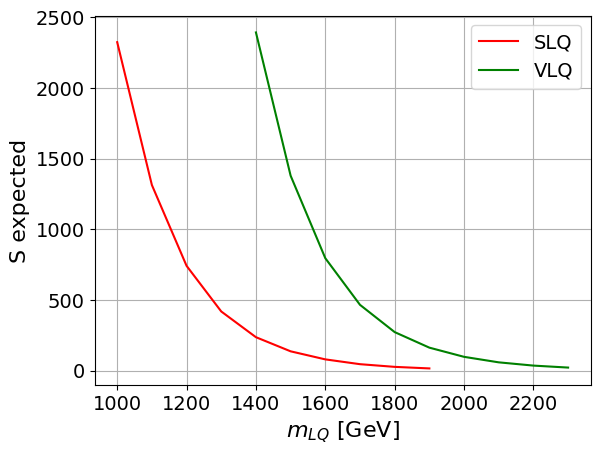

In [42]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
# plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [43]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (2325 ev)  -> VLQ 1400 GeV (2394 ev)
SLQ 1100 GeV (1314 ev)  -> VLQ 1500 GeV (1380 ev)
SLQ 1200 GeV (742 ev)  -> VLQ 1600 GeV (796 ev)
SLQ 1300 GeV (419 ev)  -> VLQ 1700 GeV (466 ev)
SLQ 1400 GeV (237 ev)  -> VLQ 1800 GeV (273 ev)
SLQ 1500 GeV (137 ev)  -> VLQ 1900 GeV (163 ev)
SLQ 1600 GeV (80 ev)  -> VLQ 2000 GeV (98 ev)
SLQ 1700 GeV (46 ev)  -> VLQ 2200 GeV (36 ev)
SLQ 1800 GeV (27 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 1900 GeV (16 ev)  -> VLQ 2300 GeV (22 ev)


### Plot

In [44]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'darkorange', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    # plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        # plt.ylim(1e-2,1e-0)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    plt.show()

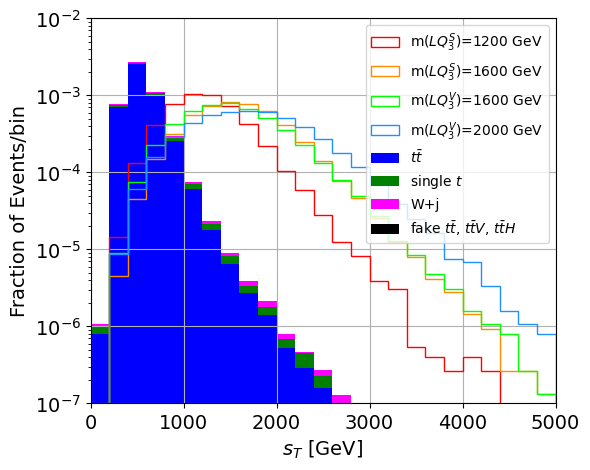

In [45]:
# Ejemple: sT
plot_variable('sT', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET
              range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              )

# 1. DATA FORMAT for CLASSIFIERS

In [46]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [47]:
# DATA WITH UNCERTAINTIES

factor_down = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_down = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_down.columns:
    df_B_all_down["sT"] = df_B_all_down["sT"] * (1 - factor_down)



df_SLQ_all_down = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_SLQ_all_down[key] = df_sample



df_VLQ_all_down = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_VLQ_all_down[key] = df_sample

In [48]:
# DATA WITH UNCERTAINTIES

factor_up = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_up = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_up.columns:
    df_B_all_up["sT"] = df_B_all_up["sT"] * (1 + factor_up)



df_SLQ_all_up = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_SLQ_all_up[key] = df_sample



df_VLQ_all_up = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_VLQ_all_up[key] = df_sample

In [49]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features_14TeV.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (300000, 53)
X_val_SM :  (75000, 53)
X_test_SM :  (187500, 53)
X_pseudo_SM :  (187500, 53)

X_train_SLQ1200 :  (15000, 53)
X_val_SLQ1200 :  (3750, 53)
X_test_SLQ1200 :  (9375, 53)
X_pseudo_SLQ1200 :  (9375, 53)

X_train_VLQ1600 :  (15000, 53)
X_val_VLQ1600 :  (3750, 53)
X_test_VLQ1600 :  (9375, 53)
X_pseudo_VLQ1600 :  (9375, 53)


In [50]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

In [51]:

# Apply normalization
df_SM_down_norm = pd.DataFrame(scaler.transform(df_B_all_down), columns=df_B_all_down.columns)
df_SLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_down[mass]), columns=df_SLQ_all_down[mass].columns) for mass in df_SLQ_all_down}
df_VLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_down[mass]), columns=df_VLQ_all_down[mass].columns) for mass in df_VLQ_all_down}

# to save memory
del df_B_all_down
del df_SLQ_all_down
del df_VLQ_all_down

In [52]:

# Apply normalization
df_SM_up_norm = pd.DataFrame(scaler.transform(df_B_all_up), columns=df_B_all_up.columns)
df_SLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_up[mass]), columns=df_SLQ_all_up[mass].columns) for mass in df_SLQ_all_up}
df_VLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_up[mass]), columns=df_VLQ_all_up[mass].columns) for mass in df_VLQ_all_up}

# to save memory
del df_B_all_up
del df_SLQ_all_up
del df_VLQ_all_up

# SM vs LQ

In [53]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test



# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

750000 750000 750000
(843750, 53)
(281250, 53)
(375000, 53)


In [54]:
# Combine all LQ in a single DataFrame
df_LQ_down_list = list(df_SLQ_down_norm.values()) + list(df_VLQ_down_norm.values())
df_LQ_down_norm = pd.concat(df_LQ_down_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_down_norm), len(df_LQ_down_norm))


# Create X, y
X_test_down = pd.concat([df_SM_down_norm, df_LQ_down_norm], ignore_index=True)
y_test_down = np.hstack([np.zeros(len(df_SM_down_norm)), np.ones(len(df_LQ_down_norm))])  # 0=SM, 1=LQ


print(X_test_down.shape)
print(y_test_down.shape)

400000 400000
(800000, 53)
(800000,)


In [55]:
# Combine all LQ in a single DataFrame
df_LQ_up_list = list(df_SLQ_up_norm.values()) + list(df_VLQ_up_norm.values())
df_LQ_up_norm = pd.concat(df_LQ_up_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_up_norm), len(df_LQ_up_norm))


# Create X, y
X_test_up = pd.concat([df_SM_up_norm, df_LQ_up_norm], ignore_index=True)
y_test_up = np.hstack([np.zeros(len(df_SM_up_norm)), np.ones(len(df_LQ_up_norm))])  # 0=SM, 1=LQ


print(X_test_up.shape)
print(y_test_up.shape)

400000 400000
(800000, 53)
(800000,)


In [ ]:
# Train
xgb_clf = XGBClassifier(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=50,
    tree_method='hist'
)

xgb_clf.fit(X_train, y_train,
            eval_set=[(X_train, y_train),
                      (X_val, y_val)],
            verbose=True)

# SAVE
xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_14TeV.json")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [05:24:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65024	validation_1-logloss:0.65028
[1]	validation_0-logloss:0.61167	validation_1-logloss:0.61176
[2]	validation_0-logloss:0.57785	validation_1-logloss:0.57800
[3]	validation_0-logloss:0.54525	validation_1-logloss:0.54545
[4]	validation_0-logloss:0.51590	validation_1-logloss:0.51613
[5]	validation_0-logloss:0.48847	validation_1-logloss:0.48874
[6]	validation_0-logloss:0.46307	validation_1-logloss:0.46338
[7]	validation_0-logloss:0.43977	validation_1-logloss:0.44011
[8]	validation_0-logloss:0.41802	validation_1-logloss:0.41839
[9]	validation_0-logloss:0.39854	validation_1-logloss:0.39895
[10]	validation_0-logloss:0.37978	validation_1-logloss:0.38022
[11]	validation_0-logloss:0.36232	validation_1-logloss:0.36280
[12]	validation_0-logloss:0.34610	validation_1-logloss:0.34661
[13]	validation_0-logloss:0.33166	validation_1-logloss:0.33219
[14]	validation_0-logloss:0.31745	validation_1-logloss:0.31801
[15]	validation_0-logloss:0.30412	validation_1-logloss:0.30472
[1

Accuracy: 0.973, ROC-AUC: 0.99655


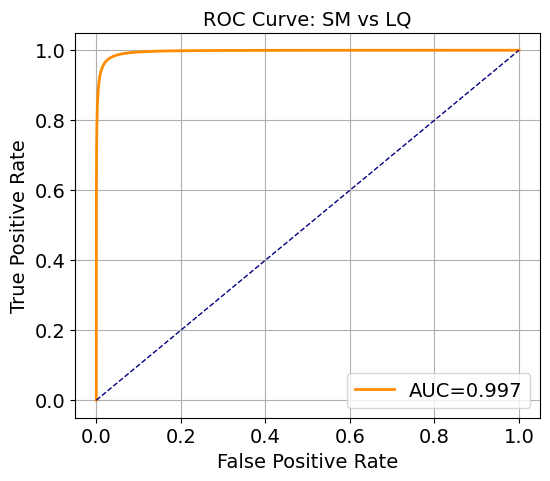

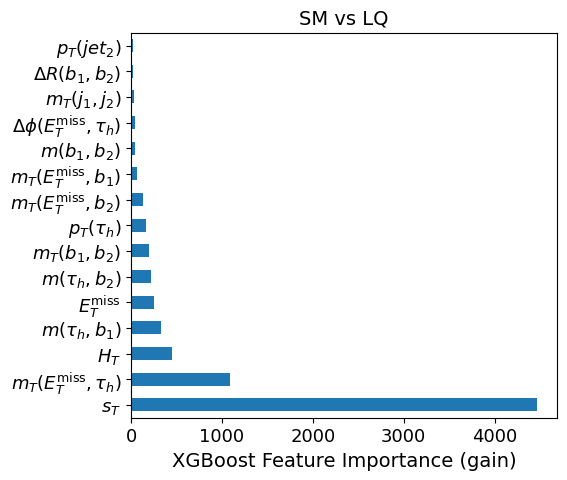

[52, 47, 17, 35, 15, 36, 50, 6, 46, 45, 37, 32, 51, 22, 12]


In [56]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_14TeV.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
# plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Accuracy: 0.976, ROC-AUC: 0.99728
Accuracy: 0.976, ROC-AUC: 0.99727


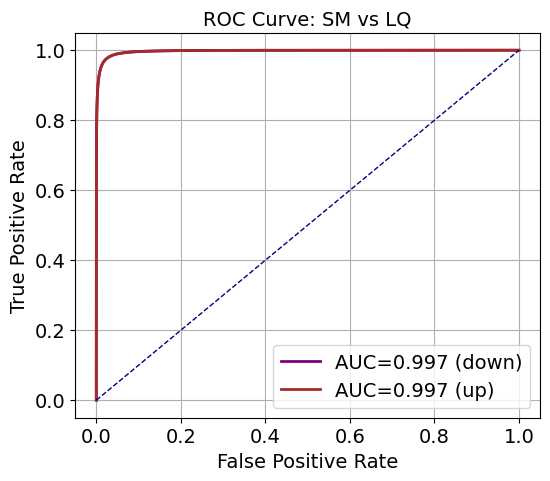

In [57]:

# Evaluate
y_pred_down = xgb_clf.predict(X_test_down)
y_pred_proba_down = xgb_clf.predict_proba(X_test_down)[:,1]

acc_down = accuracy_score(y_test_down, y_pred_down)
auc_down = roc_auc_score(y_test_down, y_pred_proba_down)
print(f"Accuracy: {acc_down:.3f}, ROC-AUC: {auc_down:.5f}")


# Evaluate
y_pred_up = xgb_clf.predict(X_test_up)
y_pred_proba_up = xgb_clf.predict_proba(X_test_up)[:,1]

acc_up = accuracy_score(y_test_up, y_pred_up)
auc_up = roc_auc_score(y_test_up, y_pred_proba_up)
print(f"Accuracy: {acc_up:.3f}, ROC-AUC: {auc_up:.5f}")

# ROC curve
fpr_down, tpr_down, _ = roc_curve(y_test_down, y_pred_proba_down)
fpr_up, tpr_up, _ = roc_curve(y_test_up, y_pred_proba_up)

plt.figure(figsize=(6,5))
plt.plot(fpr_down, tpr_down, color='purple', lw=2, label=f'AUC={auc_down:.3f} (down)')
plt.plot(fpr_up, tpr_up, color='brown', lw=2, label=f'AUC={auc_up:.3f} (up)')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


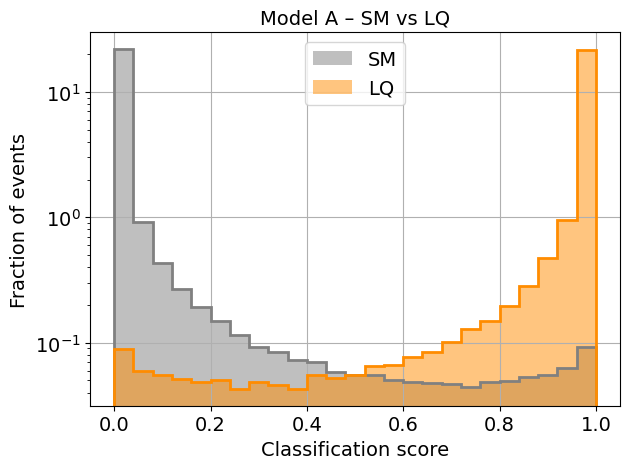

In [58]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

# Exclusion and Discovery

In [59]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

for m in masses_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [60]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_down = xgb_clf.predict_proba( df_SM_down_norm )[:,1]

scoresA_SLQ_down = {}
scoresA_VLQ_down = {}

for m in masses_SLQ:
    scoresA_SLQ_down[m] = xgb_clf.predict_proba( df_SLQ_down_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_down[m] = xgb_clf.predict_proba( df_VLQ_down_norm[m] )[:,1]

In [61]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_up = xgb_clf.predict_proba( df_SM_up_norm )[:,1]

scoresA_SLQ_up = {}
scoresA_VLQ_up = {}

for m in masses_SLQ:
    scoresA_SLQ_up[m] = xgb_clf.predict_proba( df_SLQ_up_norm[m] )[:,1]

for m in masses_VLQ:
    scoresA_VLQ_up[m] = xgb_clf.predict_proba( df_VLQ_up_norm[m] )[:,1]

#### Aux functions

In [62]:
def generate_pseudo_1output_dis(scores_B, scores_S, N_B, N_S):

    sB = np.random.choice(scores_B, N_B, replace=True)
    sS = np.random.choice(scores_S, N_S, replace=True)

    scores = np.concatenate([sB, sS])

    return scores


def generate_pseudo_1output_exc(scores_B, N_B):

    sB = np.random.choice(scores_B, N_B, replace=True)

    return sB




In [63]:
def Z_asimov_dis(S, B):
    return np.sqrt( 2 * np.sum( (S+B) * np.log(1 + S/B) - S ) )


def Z_asimov_exc(S, B):
    return np.sqrt( 2 * np.sum( S - B * np.log(1 + S/B) ) )


def f_mu_hat(mu, N, S, B):

    return sum((ni*si)/(mu*si+bi) - si for ni,si,bi in zip(N,S,B))


def q0(N,S,B,mu_hat):
    """
    this is for discovery
    q0 = −2 log( L(0)/L(μ^) )
    """
    if mu_hat <= 0:
        return 0

    return -2 * sum( ni*np.log((bi)/(mu_hat*si+bi)) - bi + (mu_hat*si+bi) for ni,si,bi in zip(N,S,B)  )


def q1(N,S,B,mu_hat):
    """
    this is for exclusion
    q1 = −2 log( L(1)/L(μ^) )
    """
    if mu_hat > 1:
        return 0
    elif mu_hat > 0:
        return -2 * sum( ni*np.log((si+bi)/(mu_hat*si+bi)) - (1-mu_hat)*si  for ni,si,bi in zip(N,S,B)  )
    else:
        return -2 * sum( ni*np.log((si+bi)/(0.*si+bi)) - (1-0.)*si  for ni,si,bi in zip(N,S,B)  )

## Z-Loop for beta=0.5

B_expected:  45962
S_expected:  2325
m_SLQ=  1000  GeV
m_VLQ=  1400  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  75.2443410530827
Z_asimov_dis_VLQ =  84.7603350176712

Z_asimov_exc_SLQ =  52.47717385450365
Z_asimov_exc_VLQ =  56.79889858517227


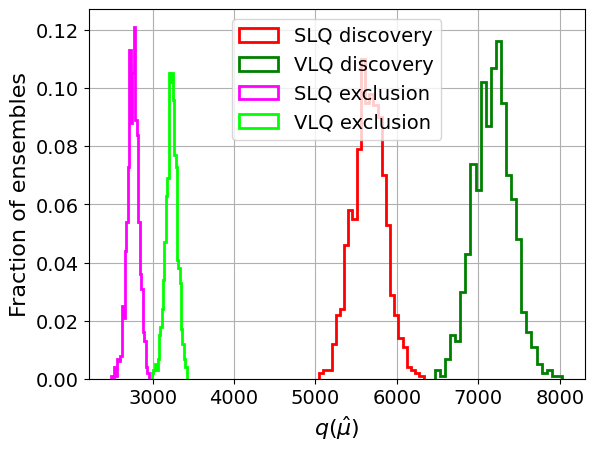


 Binned Likelihood:
Z_dis_SLQ =  75.19489583553029  +-  1.3309163530093204
Z_dis_VLQ =  84.7703613074192  +-  1.3749888424181222

Z_exc_SLQ =  52.52889161438225  +-  0.6600815154255725
Z_exc_VLQ =  56.846199645713575  +-  0.6128347005114967

------------------------------------------

B_expected:  45962
S_expected:  1314
m_SLQ=  1100  GeV
m_VLQ=  1500  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  52.16816132383566
Z_asimov_dis_VLQ =  56.29491728604957

Z_asimov_exc_SLQ =  38.289737899011236
Z_asimov_exc_VLQ =  40.4804526414104


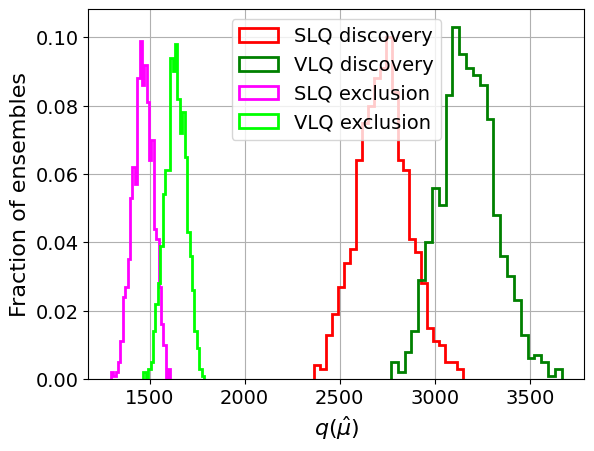


 Binned Likelihood:
Z_dis_SLQ =  52.23472506645673  +-  1.310306677019052
Z_dis_VLQ =  56.30264356364375  +-  1.3105406934712394

Z_exc_SLQ =  38.26988175843659  +-  0.6865873509633184
Z_exc_VLQ =  40.46180528384015  +-  0.6623527260398954

------------------------------------------

B_expected:  45962
S_expected:  742
m_SLQ=  1200  GeV
m_VLQ=  1600  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  34.79918288510628
Z_asimov_dis_VLQ =  36.52824645997538

Z_asimov_exc_SLQ =  27.128418525909193
Z_asimov_exc_VLQ =  28.186371167849888


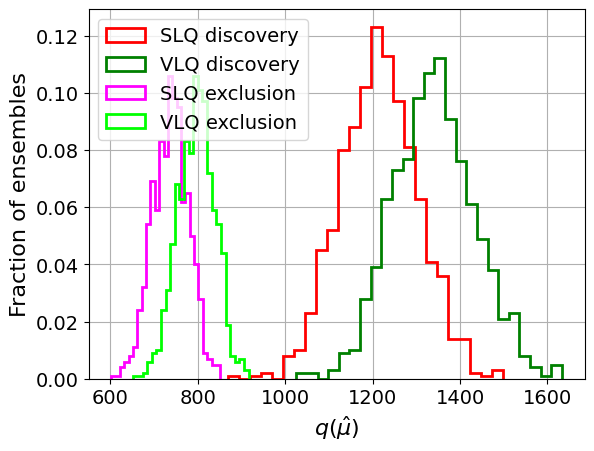


 Binned Likelihood:
Z_dis_SLQ =  34.85283477280126  +-  1.2562302428445251
Z_dis_VLQ =  36.5969174632038  +-  1.272497327932845

Z_exc_SLQ =  27.166520230899113  +-  0.7575542162206311
Z_exc_VLQ =  28.22254978574239  +-  0.7485459158115485

------------------------------------------

B_expected:  45962
S_expected:  419
m_SLQ=  1300  GeV
m_VLQ=  1700  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  22.45808691800992
Z_asimov_dis_VLQ =  23.09446183560702

Z_asimov_exc_SLQ =  18.594560779925533
Z_asimov_exc_VLQ =  19.036229316970985


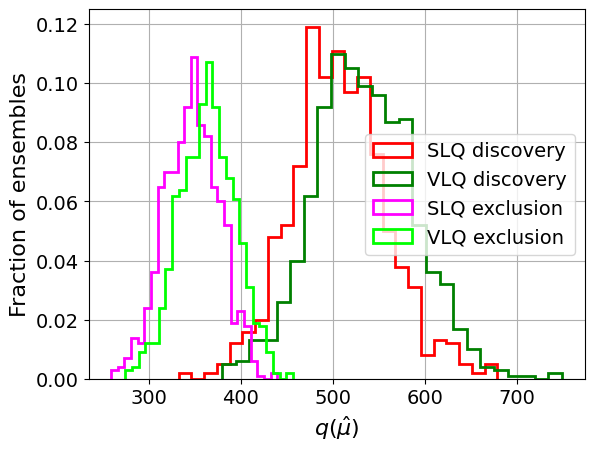


 Binned Likelihood:
Z_dis_SLQ =  22.507662140954753  +-  1.154920888959742
Z_dis_VLQ =  23.06848369960212  +-  1.1742315794175737

Z_exc_SLQ =  18.643568867715093  +-  0.7928330409647758
Z_exc_VLQ =  19.08295218971556  +-  0.7893984884337867

------------------------------------------

B_expected:  45962
S_expected:  237
m_SLQ=  1400  GeV
m_VLQ=  1800  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  14.091618503473622
Z_asimov_dis_VLQ =  14.26035955554548

Z_asimov_exc_SLQ =  12.31366579580073
Z_asimov_exc_VLQ =  12.442990825631146


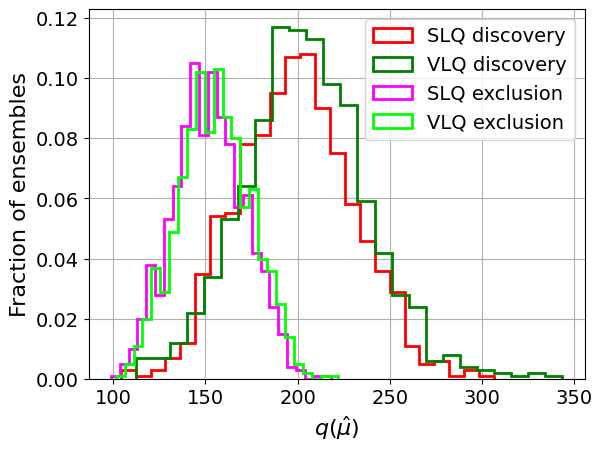


 Binned Likelihood:
Z_dis_SLQ =  14.107278201578053  +-  1.097934471172361
Z_dis_VLQ =  14.267752680887236  +-  1.1763097511685776

Z_exc_SLQ =  12.323761359974654  +-  0.7829770342438092
Z_exc_VLQ =  12.457006708136904  +-  0.7812533385062224

------------------------------------------

B_expected:  45962
S_expected:  137
m_SLQ=  1500  GeV
m_VLQ=  1900  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  8.793455438705026
Z_asimov_dis_VLQ =  8.777814030383315

Z_asimov_exc_SLQ =  8.015633024908695
Z_asimov_exc_VLQ =  8.002342966446385


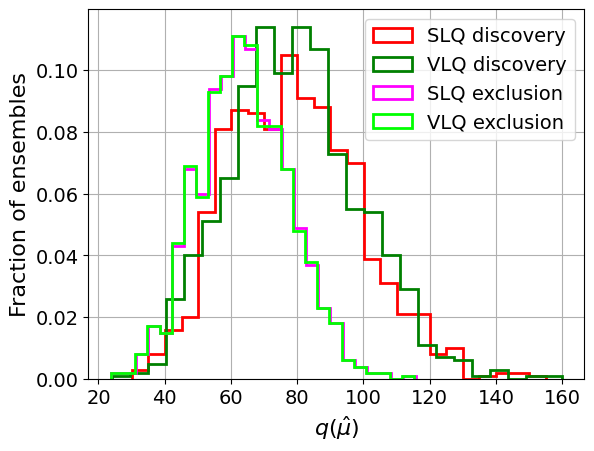


 Binned Likelihood:
Z_dis_SLQ =  8.817184417401881  +-  1.1134793804496366
Z_dis_VLQ =  8.854258765157027  +-  1.1059862678442218

Z_exc_SLQ =  7.966661110319473  +-  0.8579323906984051
Z_exc_VLQ =  7.952487354863075  +-  0.8579835299005726

------------------------------------------

B_expected:  45962
S_expected:  80
m_SLQ=  1600  GeV
m_VLQ=  2000  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  5.4181536766153
Z_asimov_dis_VLQ =  5.326939306227587

Z_asimov_exc_SLQ =  5.0969831932582474
Z_asimov_exc_VLQ =  5.015915392033899


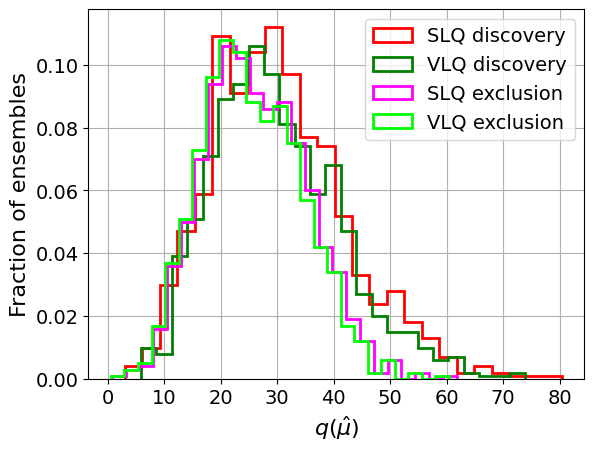


 Binned Likelihood:
Z_dis_SLQ =  5.394142049380928  +-  1.1131497344582209
Z_dis_VLQ =  5.318982120585165  +-  1.062032557734005

Z_exc_SLQ =  5.041584668507905  +-  0.8922123404960723
Z_exc_VLQ =  4.964433143597493  +-  0.891273633412373

------------------------------------------

B_expected:  45962
S_expected:  46
m_SLQ=  1700  GeV
m_VLQ=  2100  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  3.230473401031896
Z_asimov_dis_VLQ =  3.148833309038482

Z_asimov_exc_SLQ =  3.109298142704821
Z_asimov_exc_VLQ =  3.03353503373038


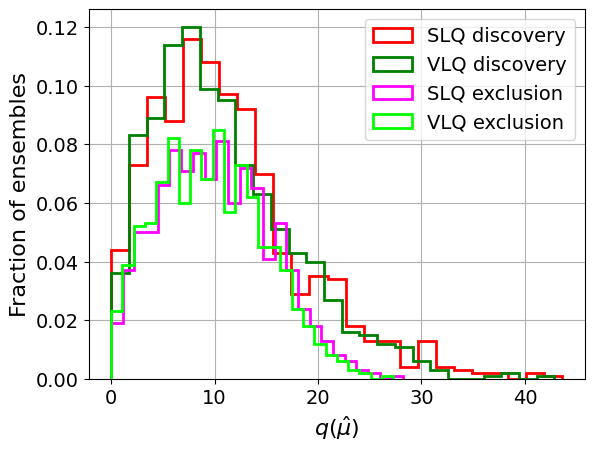


 Binned Likelihood:
Z_dis_SLQ =  3.1721996433842103  +-  1.13257621268335
Z_dis_VLQ =  3.0901975105715827  +-  1.0998650458197283

Z_exc_SLQ =  3.15652582339392  +-  0.8381770805450021
Z_exc_VLQ =  3.0824198347888894  +-  0.8353286370411881

------------------------------------------

B_expected:  45962
S_expected:  27
m_SLQ=  1800  GeV
m_VLQ=  2200  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.938940538904698
Z_asimov_dis_VLQ =  1.889087630663331

Z_asimov_exc_SLQ =  1.8936211627688908
Z_asimov_exc_VLQ =  1.8460386207272907


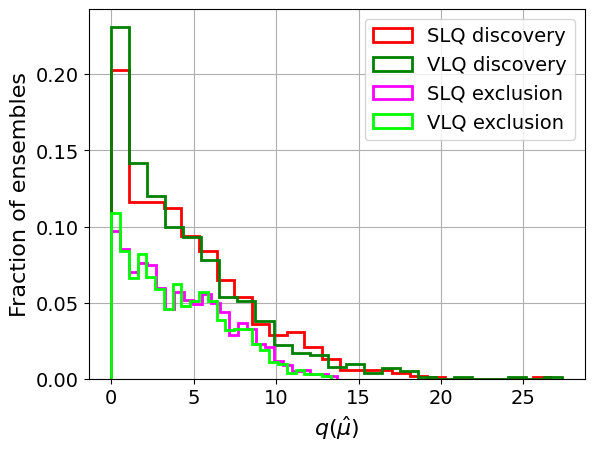


 Binned Likelihood:
Z_dis_SLQ =  1.9405032795902608  +-  1.0075155958993998
Z_dis_VLQ =  1.83484643719713  +-  1.0891375195528157

Z_exc_SLQ =  1.9222436550064246  +-  0.7869657553485417
Z_exc_VLQ =  1.8821467211976455  +-  0.780476174608511

------------------------------------------

B_expected:  45962
S_expected:  16
m_SLQ=  1900  GeV
m_VLQ=  2300  GeV

 Asimov datasets:
Z_asimov_dis_SLQ =  1.168266107955174
Z_asimov_dis_VLQ =  1.1259974583188976

Z_asimov_exc_SLQ =  1.1514249601584787
Z_asimov_exc_VLQ =  1.110348522457091


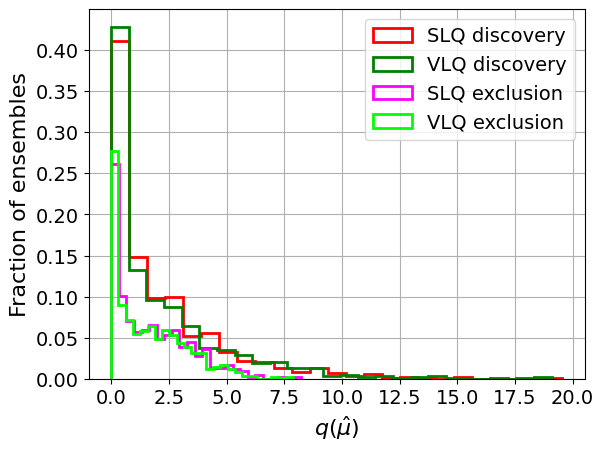


 Binned Likelihood:
Z_dis_SLQ =  1.1322271073549466  +-  1.1529211766259178
Z_dis_VLQ =  1.0654246420988973  +-  1.2774687820407358

Z_exc_SLQ =  1.1796160736385928  +-  0.6904321177779857
Z_exc_VLQ =  1.1341870536298284  +-  0.6879256743027784

------------------------------------------



In [64]:

S_expected = S_expected_SLQ

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



Z_asimov_dis_SLQ = []
Z_asimov_exc_SLQ = []

Z_asimov_dis_VLQ = []
Z_asimov_exc_VLQ = []


Z_dis_SLQ = []
Z_exc_SLQ = []

Z_dis_VLQ = []
Z_exc_VLQ = []

Z_dis_std_SLQ = []
Z_exc_std_SLQ = []

Z_dis_std_VLQ = []
Z_exc_std_VLQ = []



for m_it in range(len(masses_SLQ)):

    print('B_expected: ', B_expected)
    print('S_expected: ', S_expected[m_it])

    mass_SLQ = masses_SLQ[m_it]
    mass_VLQ = masses_VLQ[m_it]

    print('m_SLQ= ', mass_SLQ, ' GeV' )
    print('m_VLQ= ', mass_VLQ, ' GeV' )

    if S_expected[m_it] == 0:

        Z_asimov_dis_SLQ.append(0)
        Z_asimov_exc_SLQ.append(0)

        Z_asimov_dis_VLQ.append(0)
        Z_asimov_exc_VLQ.append(0)

        Z_dis_SLQ.append(0)
        Z_dis_std_SLQ.append(1)
        Z_exc_SLQ.append(0)
        Z_exc_std_SLQ.append(1)

        Z_dis_VLQ.append(0)
        Z_dis_std_VLQ.append(1)
        Z_exc_VLQ.append(0)
        Z_exc_std_VLQ.append(1)

        continue


    ###################
    # ASIMOV EXPECTED #
    ###################

    # SLQ PDF
    hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
    S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected[m_it])

    # VLQ PDF
    hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
    S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected[m_it])


    Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
    Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

    Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
    Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


    Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
    Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

    Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
    Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


    print('\n Asimov datasets:')
    print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
    print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
    print()
    print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
    print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





    #####################
    # BINNED LIKELIHOOD #
    #####################

    q_dis_SLQ = []
    q_exc_SLQ = []

    q_dis_VLQ = []
    q_exc_VLQ = []


    for pexp_it in range(n_pseudo):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_expected[m_it])


        # pseudo experiment (DISCOVERY: SM vs SM+LQ)
        # SLQ
        scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
        N_pseudo_SLQ = hist

        # VLQ
        scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S )
        hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
        N_pseudo_VLQ = hist


        # pseudo experiment (EXCLUSION: SM ONLY)
        # SLQ and VLQ (since no signal)
        scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
        hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
        N_pseudo_EXC = hist



        # DISCOVERY (mu_hat=1 idedally)
        # SLQ
        mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
        q_dis_SLQ.append(q_dis_SLQ_it)


        # VLQ
        mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

        q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
        q_dis_VLQ.append(q_dis_VLQ_it)



        # EXCLUSION (mu_hat=0 idedally)
        # SLQ
        mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
        q_exc_SLQ.append(q_exc_SLQ_it)


        # VLQ
        mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

        q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
        q_exc_VLQ.append(q_exc_VLQ_it)




    # Histogram of q_muhats
    weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
    weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

    weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
    weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
    nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
    #plt.xlim(0,1)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(r"$q(\hat{\mu})$",fontsize=16)
    plt.ylabel("Fraction of ensembles",fontsize=16)
    plt.grid()
    plt.legend(fontsize=14)
    plt.show()




    Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
    Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

    Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
    Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


    Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
    Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

    Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
    Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


    Z_dis_SLQ.append(Z_dis_SLQ_it)
    Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
    Z_exc_SLQ.append(Z_exc_SLQ_it)
    Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

    Z_dis_VLQ.append(Z_dis_VLQ_it)
    Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
    Z_exc_VLQ.append(Z_exc_VLQ_it)
    Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


    print('\n Binned Likelihood:')
    print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
    print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
    print()
    print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
    print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)


    print('\n------------------------------------------\n')

m_asimov_dis_SLQ =  1619.1140214263617  GeV
m_asimov_dis_VLQ =  2015.0102569227352  GeV

m_asimov_exc_SLQ =  1833.5177591777574  GeV
m_asimov_exc_VLQ =  2227.346432179644  GeV

m_BL_dis_SLQ =  1617.7386258220372  GeV
m_BL_dis_VLQ =  2014.3119312270924  GeV

m_BL_exc_SLQ =  1837.352508176983  GeV
m_BL_exc_VLQ =  2231.725386345736  GeV


/tmp/ipykernel_3040/2666492215.py:22: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_3040/2666492215.py:25: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_3040/2666492215.py:28: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]
/tmp/ipykernel_3040/2666492215.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
/tmp/ipykernel_3040/2666492215.py:31: RuntimeWarning: The iteration 

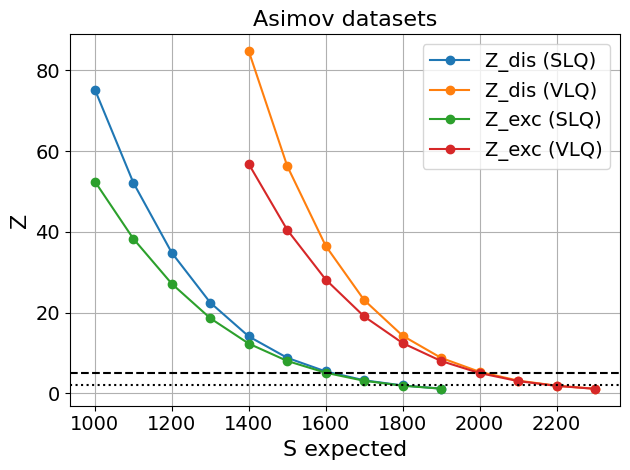

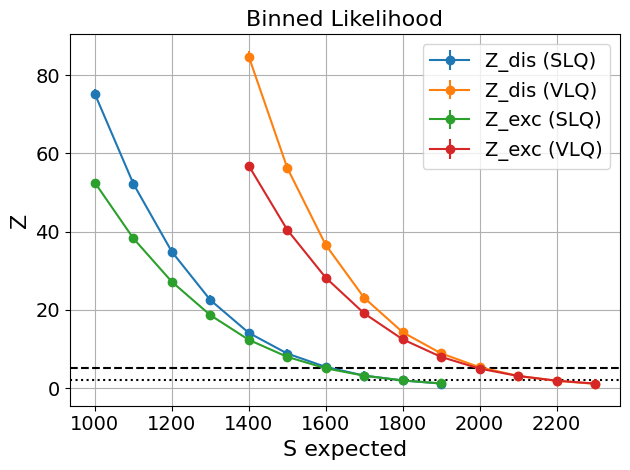

In [65]:
# Z value that we want
Z_dis = 5
Z_exc = stats.norm.isf(0.05)

#  interpolate
f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")


# find the mass such that we get Z for discovery or exclusion

m_asimov_dis_SLQ = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
m_asimov_exc_SLQ = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

m_asimov_dis_VLQ = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1600)[0]
m_asimov_exc_VLQ = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1600)[0]

m_BL_dis_SLQ = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
m_BL_exc_SLQ = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

m_BL_dis_VLQ = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1600)[0]
m_BL_exc_VLQ = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1600)[0]



print(r'm_asimov_dis_SLQ = ', m_asimov_dis_SLQ, ' GeV')
print(r'm_asimov_dis_VLQ = ', m_asimov_dis_VLQ, ' GeV')
print()
print(r'm_asimov_exc_SLQ = ', m_asimov_exc_SLQ, ' GeV')
print(r'm_asimov_exc_VLQ = ', m_asimov_exc_VLQ, ' GeV')

print()
print(r'm_BL_dis_SLQ = ', m_BL_dis_SLQ, ' GeV')
print(r'm_BL_dis_VLQ = ', m_BL_dis_VLQ, ' GeV')
print()
print(r'm_BL_exc_SLQ = ', m_BL_exc_SLQ, ' GeV')
print(r'm_BL_exc_VLQ = ', m_BL_exc_VLQ, ' GeV')





# plot ASIMOV DATASETS

plt.plot(masses_SLQ, Z_asimov_dis_SLQ, 'o-', label='Z_dis (SLQ)')
plt.plot(masses_VLQ, Z_asimov_dis_VLQ, 'o-', label='Z_dis (VLQ)')

plt.plot(masses_SLQ, Z_asimov_exc_SLQ, 'o-', label='Z_exc (SLQ)')
plt.plot(masses_VLQ, Z_asimov_exc_VLQ, 'o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.errorbar(masses_SLQ, Z_dis_SLQ, yerr=Z_dis_std_SLQ, fmt='o-', label='Z_dis (SLQ)')
plt.errorbar(masses_VLQ, Z_dis_VLQ, yerr=Z_dis_std_VLQ, fmt='o-', label='Z_dis (VLQ)')

plt.errorbar(masses_SLQ, Z_exc_SLQ, yerr=Z_exc_std_SLQ, fmt='o-', label='Z_exc (SLQ)')
plt.errorbar(masses_VLQ, Z_exc_VLQ, yerr=Z_exc_std_VLQ, fmt='o-', label='Z_exc (VLQ)')

plt.axhline(y=5, linestyle='--', color='black')
plt.axhline(y=2, linestyle=':', color='black')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("S expected",fontsize=16)
plt.ylabel("Z",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Z-Loop for all betas

In [66]:
# Z value that we want
# Z_dis = 5
Z_dis = 3
Z_exc = stats.norm.isf(0.05)
Z_exc

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

In [44]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_14TeV = []
m_asimov_exc_SLQ_14TeV = []

m_asimov_dis_VLQ_14TeV = []
m_asimov_exc_VLQ_14TeV = []


m_BL_dis_SLQ_14TeV = []
m_BL_exc_SLQ_14TeV = []

m_BL_dis_VLQ_14TeV = []
m_BL_exc_VLQ_14TeV = []


m_BL_dis_SLQ_low_14TeV = []
m_BL_exc_SLQ_low_14TeV = []

m_BL_dis_VLQ_low_14TeV = []
m_BL_exc_VLQ_low_14TeV = []


m_BL_dis_SLQ_high_14TeV = []
m_BL_exc_SLQ_high_14TeV = []

m_BL_dis_VLQ_high_14TeV = []
m_BL_exc_VLQ_high_14TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_14TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_14TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_SLQ[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM, scoresA_VLQ[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1800)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1800)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_14TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_14TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_14TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_14TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_14TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_14TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_14TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_14TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_14TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_14TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_14TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_14TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_14TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_14TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_14TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_14TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

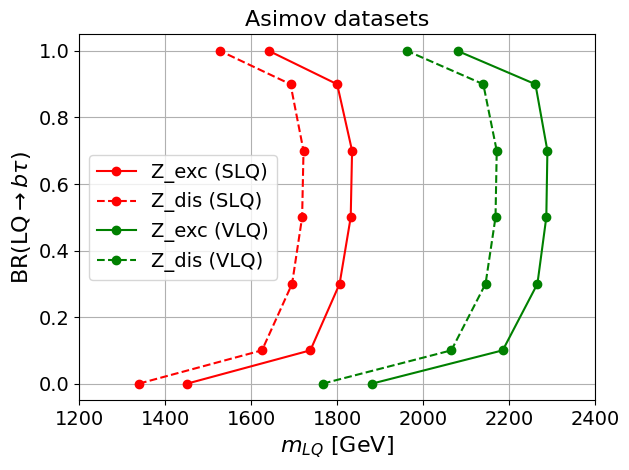

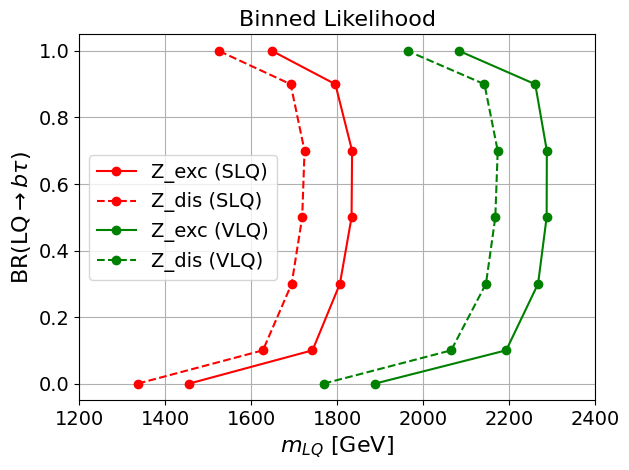

In [45]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [46]:

# SAVE

file_path = mainfolder + 'saved-results/Z14TeV_err_Z3.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_14TeV,
    m_asimov_dis_SLQ_14TeV,
    m_asimov_exc_VLQ_14TeV,
    m_asimov_dis_VLQ_14TeV,
    m_BL_exc_SLQ_14TeV,
    m_BL_dis_SLQ_14TeV,
    m_BL_exc_VLQ_14TeV,
    m_BL_dis_VLQ_14TeV,
    m_BL_exc_SLQ_low_14TeV,
    m_BL_dis_SLQ_low_14TeV,
    m_BL_exc_VLQ_low_14TeV,
    m_BL_dis_VLQ_low_14TeV,
    m_BL_exc_SLQ_high_14TeV,
    m_BL_dis_SLQ_high_14TeV,
    m_BL_exc_VLQ_high_14TeV,
    m_BL_dis_VLQ_high_14TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_14TeV m_asimov_dis_SLQ_14TeV m_asimov_exc_VLQ_14TeV m_asimov_dis_VLQ_14TeV m_BL_exc_SLQ_14TeV m_BL_dis_SLQ_14TeV m_BL_exc_VLQ_14TeV m_BL_dis_VLQ_14TeV m_BL_exc_SLQ_low_14TeV m_BL_dis_SLQ_low_14TeV m_BL_exc_VLQ_low_14TeV m_BL_dis_VLQ_low_14TeV m_BL_exc_SLQ_high_14TeV m_BL_dis_SLQ_high_14TeV m_BL_exc_VLQ_high_14TeV m_BL_dis_VLQ_high_14TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z14TeV_err_Z3.txt


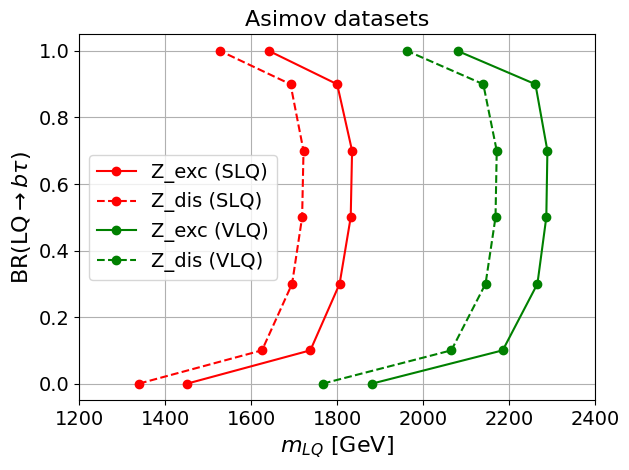

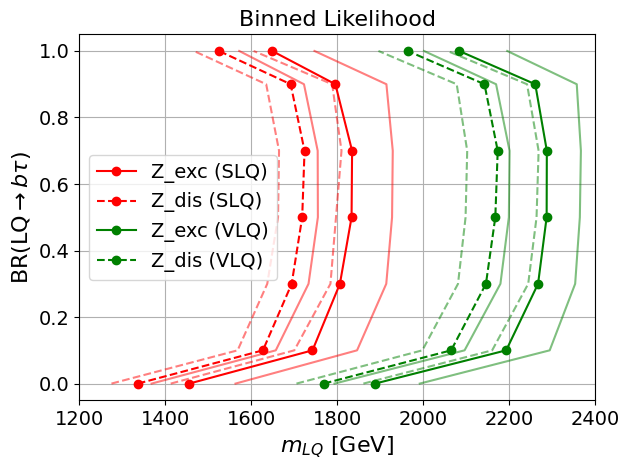

In [74]:

# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_Z3.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]



# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### down

In [48]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_14TeV = []
m_asimov_exc_SLQ_14TeV = []

m_asimov_dis_VLQ_14TeV = []
m_asimov_exc_VLQ_14TeV = []


m_BL_dis_SLQ_14TeV = []
m_BL_exc_SLQ_14TeV = []

m_BL_dis_VLQ_14TeV = []
m_BL_exc_VLQ_14TeV = []


m_BL_dis_SLQ_low_14TeV = []
m_BL_exc_SLQ_low_14TeV = []

m_BL_dis_VLQ_low_14TeV = []
m_BL_exc_VLQ_low_14TeV = []


m_BL_dis_SLQ_high_14TeV = []
m_BL_exc_SLQ_high_14TeV = []

m_BL_dis_VLQ_high_14TeV = []
m_BL_exc_VLQ_high_14TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_14TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_14TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_SLQ_down[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_down, scoresA_VLQ_down[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_down, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1800)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1800)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_14TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_14TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_14TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_14TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_14TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_14TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_14TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_14TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_14TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_14TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_14TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_14TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_14TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_14TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_14TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_14TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

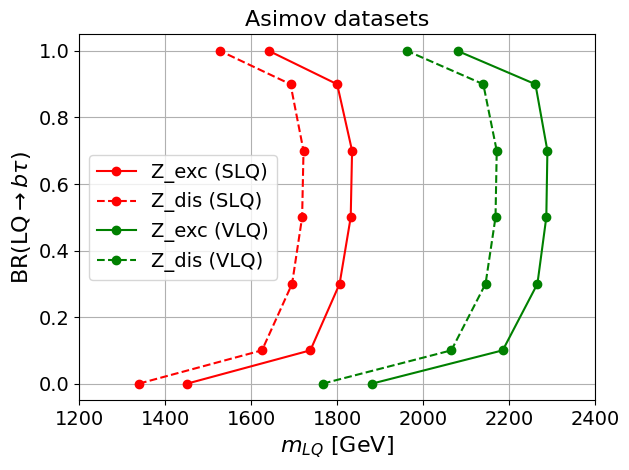

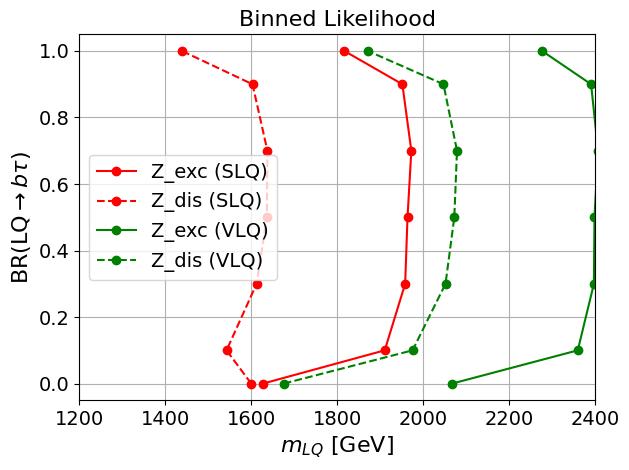

In [49]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [50]:

# SAVE

file_path = mainfolder + 'saved-results/Z14TeV_err_down_Z3.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_14TeV,
    m_asimov_dis_SLQ_14TeV,
    m_asimov_exc_VLQ_14TeV,
    m_asimov_dis_VLQ_14TeV,
    m_BL_exc_SLQ_14TeV,
    m_BL_dis_SLQ_14TeV,
    m_BL_exc_VLQ_14TeV,
    m_BL_dis_VLQ_14TeV,
    m_BL_exc_SLQ_low_14TeV,
    m_BL_dis_SLQ_low_14TeV,
    m_BL_exc_VLQ_low_14TeV,
    m_BL_dis_VLQ_low_14TeV,
    m_BL_exc_SLQ_high_14TeV,
    m_BL_dis_SLQ_high_14TeV,
    m_BL_exc_VLQ_high_14TeV,
    m_BL_dis_VLQ_high_14TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_14TeV m_asimov_dis_SLQ_14TeV m_asimov_exc_VLQ_14TeV m_asimov_dis_VLQ_14TeV m_BL_exc_SLQ_14TeV m_BL_dis_SLQ_14TeV m_BL_exc_VLQ_14TeV m_BL_dis_VLQ_14TeV m_BL_exc_SLQ_low_14TeV m_BL_dis_SLQ_low_14TeV m_BL_exc_VLQ_low_14TeV m_BL_dis_VLQ_low_14TeV m_BL_exc_SLQ_high_14TeV m_BL_dis_SLQ_high_14TeV m_BL_exc_VLQ_high_14TeV m_BL_dis_VLQ_high_14TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z14TeV_err_down_Z3.txt


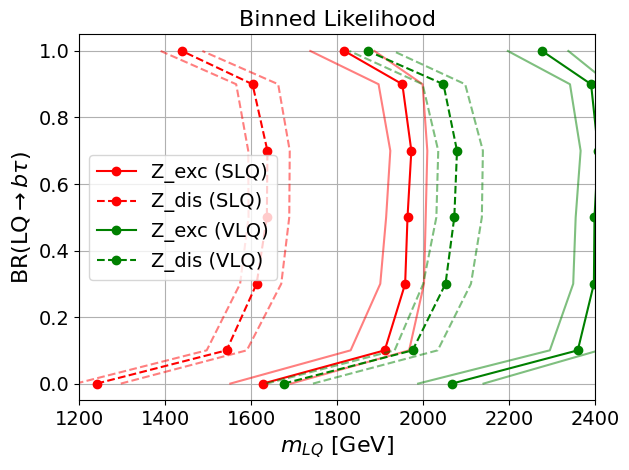

In [23]:

# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_down_Z3.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV_down = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV_down = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV_down = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV_down = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV_down = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV_down = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV_down = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV_down = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV_down = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV_down = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV_down = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV_down = loaded_data[:, 16]





# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV_down, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV_down, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV_down, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV_down, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV_down, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_14TeV_down, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV_down, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV_down, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV_down, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV_down, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### up

In [79]:

betas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

n_pseudo = 1000


N_bins = 16

# SM PDF
hist_SM, edges = np.histogram(scoresA_SM, bins=N_bins, range=(0,1))
B_template = hist_SM / (len(scoresA_SM) / B_expected)



m_asimov_dis_SLQ_14TeV = []
m_asimov_exc_SLQ_14TeV = []

m_asimov_dis_VLQ_14TeV = []
m_asimov_exc_VLQ_14TeV = []


m_BL_dis_SLQ_14TeV = []
m_BL_exc_SLQ_14TeV = []

m_BL_dis_VLQ_14TeV = []
m_BL_exc_VLQ_14TeV = []


m_BL_dis_SLQ_low_14TeV = []
m_BL_exc_SLQ_low_14TeV = []

m_BL_dis_VLQ_low_14TeV = []
m_BL_exc_VLQ_low_14TeV = []


m_BL_dis_SLQ_high_14TeV = []
m_BL_exc_SLQ_high_14TeV = []

m_BL_dis_VLQ_high_14TeV = []
m_BL_exc_VLQ_high_14TeV = []


for b_it in betas:

    print('beta: ', b_it)

    Z_asimov_dis_SLQ = []
    Z_asimov_exc_SLQ = []

    Z_asimov_dis_VLQ = []
    Z_asimov_exc_VLQ = []


    Z_dis_SLQ = []
    Z_exc_SLQ = []

    Z_dis_VLQ = []
    Z_exc_VLQ = []

    Z_dis_std_SLQ = []
    Z_exc_std_SLQ = []

    Z_dis_std_VLQ = []
    Z_exc_std_VLQ = []


    for m_it in range(len(masses_SLQ)):

        print('B_expected: ', B_expected)

        S_expected_SLQ = fid_xsec_SLQ_14TeV(masses_SLQ[m_it], b_it) * Lum
        S_expected_VLQ = fid_xsec_VLQ_14TeV(masses_VLQ[m_it], b_it) * Lum

        print('S_expected_SLQ: ', S_expected_SLQ)
        print('S_expected_VLQ: ', S_expected_VLQ)

        mass_SLQ = masses_SLQ[m_it]
        mass_VLQ = masses_VLQ[m_it]

        print('m_SLQ= ', mass_SLQ, ' GeV' )
        print('m_VLQ= ', mass_VLQ, ' GeV' )


        if S_expected_SLQ == 0 or S_expected_VLQ == 0:

            Z_asimov_dis_SLQ.append(0)
            Z_asimov_exc_SLQ.append(0)

            Z_asimov_dis_VLQ.append(0)
            Z_asimov_exc_VLQ.append(0)

            Z_dis_SLQ.append(0)
            Z_dis_std_SLQ.append(1)
            Z_exc_SLQ.append(0)
            Z_exc_std_SLQ.append(1)

            Z_dis_VLQ.append(0)
            Z_dis_std_VLQ.append(1)
            Z_exc_VLQ.append(0)
            Z_exc_std_VLQ.append(1)

            continue



        ###################
        # ASIMOV EXPECTED #
        ###################

        # SLQ PDF
        hist_SLQ, _ = np.histogram(scoresA_SLQ[mass_SLQ], bins=N_bins, range=(0,1))
        S_template_SLQ = hist_SLQ / (len(scoresA_SLQ[mass_SLQ]) / S_expected_SLQ)

        # SLQ PDF
        hist_VLQ, _ = np.histogram(scoresA_VLQ[mass_VLQ], bins=N_bins, range=(0,1))
        S_template_VLQ = hist_VLQ / (len(scoresA_VLQ[mass_VLQ]) / S_expected_VLQ)


        Z_asimov_dis_SLQ_it = Z_asimov_dis(S_template_SLQ, B_template)
        Z_asimov_exc_SLQ_it = Z_asimov_exc(S_template_SLQ, B_template)

        Z_asimov_dis_VLQ_it = Z_asimov_dis(S_template_VLQ, B_template)
        Z_asimov_exc_VLQ_it = Z_asimov_exc(S_template_VLQ, B_template)


        Z_asimov_dis_SLQ.append(Z_asimov_dis_SLQ_it)
        Z_asimov_exc_SLQ.append(Z_asimov_exc_SLQ_it)

        Z_asimov_dis_VLQ.append(Z_asimov_dis_VLQ_it)
        Z_asimov_exc_VLQ.append(Z_asimov_exc_VLQ_it)


        print('\n Asimov datasets:')
        print('Z_asimov_dis_SLQ = ', Z_asimov_dis_SLQ_it)
        print('Z_asimov_dis_VLQ = ', Z_asimov_dis_VLQ_it)
        print()
        print('Z_asimov_exc_SLQ = ', Z_asimov_exc_SLQ_it)
        print('Z_asimov_exc_VLQ = ', Z_asimov_exc_VLQ_it)





        #####################
        # BINNED LIKELIHOOD #
        #####################

        q_dis_SLQ = []
        q_exc_SLQ = []

        q_dis_VLQ = []
        q_exc_VLQ = []


        for pexp_it in range(n_pseudo):

            N_B = np.random.poisson(B_expected)
            N_S_SLQ = np.random.poisson(S_expected_SLQ)
            N_S_VLQ = np.random.poisson(S_expected_VLQ)


            # pseudo experiment (DISCOVERY: SM vs SM+LQ)
            # SLQ
            scoresA_pseudo_SLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_SLQ_up[mass_SLQ], N_B, N_S_SLQ )
            hist, _ = np.histogram(scoresA_pseudo_SLQ, bins=N_bins, range=(0,1))
            N_pseudo_SLQ = hist

            # VLQ
            scoresA_pseudo_VLQ = generate_pseudo_1output_dis( scoresA_SM_up, scoresA_VLQ_up[mass_VLQ], N_B, N_S_VLQ )
            hist, _ = np.histogram(scoresA_pseudo_VLQ, bins=N_bins, range=(0,1))
            N_pseudo_VLQ = hist


            # pseudo experiment (EXCLUSION: SM ONLY)
            # SLQ and VLQ (since no signal)
            scoresA_pseudo_EXC = generate_pseudo_1output_exc( scoresA_SM_up, N_B )
            hist, _ = np.histogram(scoresA_pseudo_EXC, bins=N_bins, range=(0,1))
            N_pseudo_EXC = hist



            # DISCOVERY (mu_hat=1 idedally)
            # SLQ
            mu_hat_dis_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_SLQ, S_template_SLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_SLQ_it = q0(N_pseudo_SLQ, S_template_SLQ, B_template, mu_hat_dis_SLQ)
            q_dis_SLQ.append(q_dis_SLQ_it)


            # VLQ
            mu_hat_dis_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_VLQ, S_template_VLQ, B_template),1)[0] # search around mu=1 for discovery

            q_dis_VLQ_it = q0(N_pseudo_VLQ, S_template_VLQ, B_template, mu_hat_dis_VLQ)
            q_dis_VLQ.append(q_dis_VLQ_it)



            # EXCLUSION (mu_hat=0 idedally)
            # SLQ
            mu_hat_exc_SLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_SLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_SLQ_it = q1(N_pseudo_EXC, S_template_SLQ, B_template, mu_hat_exc_SLQ)
            q_exc_SLQ.append(q_exc_SLQ_it)


            # VLQ
            mu_hat_exc_VLQ = fsolve(lambda x: f_mu_hat(x, N_pseudo_EXC, S_template_VLQ, B_template),0)[0] # search around mu=0 for exclusion

            q_exc_VLQ_it = q1(N_pseudo_EXC, S_template_VLQ, B_template, mu_hat_exc_VLQ)
            q_exc_VLQ.append(q_exc_VLQ_it)




        # Histogram of q_muhats
        weights = np.ones_like(q_dis_SLQ)/float(len(q_dis_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_SLQ, 25, weights=weights, histtype='step', color='red', linewidth=2, label='SLQ discovery')
        weights = np.ones_like(q_dis_VLQ)/float(len(q_dis_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_dis_VLQ, 25, weights=weights, histtype='step', color='green', linewidth=2, label='VLQ discovery')

        weights = np.ones_like(q_exc_SLQ)/float(len(q_exc_SLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_SLQ, 25, weights=weights, histtype='step', color='magenta', linewidth=2, label='SLQ exclusion')
        weights = np.ones_like(q_exc_VLQ)/float(len(q_exc_VLQ))
        nMIX, binsMIX, patchesMIX = plt.hist(q_exc_VLQ, 25, weights=weights, histtype='step', color='lime', linewidth=2, label='VLQ exclusion')
        #plt.xlim(0,1)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel("$q(\hat{\mu})$",fontsize=16)
        plt.ylabel("Fraction of ensembles",fontsize=16)
        plt.grid()
        plt.legend(fontsize=14)
        plt.show()




        Z_dis_SLQ_it = np.sqrt(np.median(q_dis_SLQ))
        Z_dis_std_SLQ_it = np.std(q_dis_SLQ) / (2. * Z_dis_SLQ_it)

        Z_exc_SLQ_it = np.sqrt(np.median(q_exc_SLQ))
        Z_exc_std_SLQ_it = np.std(q_exc_SLQ) / (2. * Z_exc_SLQ_it)


        Z_dis_VLQ_it = np.sqrt(np.median(q_dis_VLQ))
        Z_dis_std_VLQ_it = np.std(q_dis_VLQ) / (2. * Z_dis_VLQ_it)

        Z_exc_VLQ_it = np.sqrt(np.median(q_exc_VLQ))
        Z_exc_std_VLQ_it = np.std(q_exc_VLQ) / (2. * Z_exc_VLQ_it)


        Z_dis_SLQ.append(Z_dis_SLQ_it)
        Z_dis_std_SLQ.append(Z_dis_std_SLQ_it)
        Z_exc_SLQ.append(Z_exc_SLQ_it)
        Z_exc_std_SLQ.append(Z_exc_std_SLQ_it)

        Z_dis_VLQ.append(Z_dis_VLQ_it)
        Z_dis_std_VLQ.append(Z_dis_std_VLQ_it)
        Z_exc_VLQ.append(Z_exc_VLQ_it)
        Z_exc_std_VLQ.append(Z_exc_std_VLQ_it)


        print('\n Binned Likelihood:')
        print('Z_dis_SLQ = ', Z_dis_SLQ_it, ' +- ', Z_dis_std_SLQ_it)
        print('Z_dis_VLQ = ', Z_dis_VLQ_it, ' +- ', Z_dis_std_VLQ_it)
        print()
        print('Z_exc_SLQ = ', Z_exc_SLQ_it, ' +- ', Z_exc_std_SLQ_it)
        print('Z_exc_VLQ = ', Z_exc_VLQ_it, ' +- ', Z_exc_std_VLQ_it)



        print('\n------------------------------------------\n')


    Z_dis_SLQ_low = [i-j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_low = [i-j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_low = [i-j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_low = [i-j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    Z_dis_SLQ_high = [i+j for i,j in zip(Z_dis_SLQ, Z_dis_std_SLQ)]
    Z_exc_SLQ_high = [i+j for i,j in zip(Z_exc_SLQ, Z_exc_std_SLQ)]

    Z_dis_VLQ_high = [i+j for i,j in zip(Z_dis_VLQ, Z_dis_std_VLQ)]
    Z_exc_VLQ_high = [i+j for i,j in zip(Z_exc_VLQ, Z_exc_std_VLQ)]

    #  interpolate
    f_Z_asimov_dis_SLQ = interp1d(masses_SLQ, Z_asimov_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_SLQ = interp1d(masses_SLQ, Z_asimov_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_asimov_dis_VLQ = interp1d(masses_VLQ, Z_asimov_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_asimov_exc_VLQ = interp1d(masses_VLQ, Z_asimov_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ = interp1d(masses_SLQ, Z_dis_SLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ = interp1d(masses_SLQ, Z_exc_SLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ = interp1d(masses_VLQ, Z_dis_VLQ, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ = interp1d(masses_VLQ, Z_exc_VLQ, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_low = interp1d(masses_SLQ, Z_dis_SLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_low = interp1d(masses_SLQ, Z_exc_SLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_low = interp1d(masses_VLQ, Z_dis_VLQ_low, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_low = interp1d(masses_VLQ, Z_exc_VLQ_low, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_SLQ_high = interp1d(masses_SLQ, Z_dis_SLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_SLQ_high = interp1d(masses_SLQ, Z_exc_SLQ_high, kind='linear', fill_value="extrapolate")

    f_Z_BL_dis_VLQ_high = interp1d(masses_VLQ, Z_dis_VLQ_high, kind='linear', fill_value="extrapolate")
    f_Z_BL_exc_VLQ_high = interp1d(masses_VLQ, Z_exc_VLQ_high, kind='linear', fill_value="extrapolate")


    # find the mass such that we get Z for discovery or exclusion

    m_asimov_dis_SLQ_aux = fsolve(lambda x: f_Z_asimov_dis_SLQ(x) - Z_dis,1600)[0]
    m_asimov_exc_SLQ_aux = fsolve(lambda x: f_Z_asimov_exc_SLQ(x) - Z_exc,1600)[0]

    m_asimov_dis_VLQ_aux = fsolve(lambda x: f_Z_asimov_dis_VLQ(x) - Z_dis,1800)[0]
    m_asimov_exc_VLQ_aux = fsolve(lambda x: f_Z_asimov_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_aux = fsolve(lambda x: f_Z_BL_dis_SLQ(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_aux = fsolve(lambda x: f_Z_BL_exc_SLQ(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_aux = fsolve(lambda x: f_Z_BL_dis_VLQ(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_aux = fsolve(lambda x: f_Z_BL_exc_VLQ(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_low(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_low(x) - Z_exc,1700)[0]

    m_BL_dis_VLQ_low_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_low(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_low_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_low(x) - Z_exc,1800)[0]

    m_BL_dis_SLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_SLQ_high(x) - Z_dis,1600)[0]
    m_BL_exc_SLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_SLQ_high(x) - Z_exc,1600)[0]

    m_BL_dis_VLQ_high_aux = fsolve(lambda x: f_Z_BL_dis_VLQ_high(x) - Z_dis,1800)[0]
    m_BL_exc_VLQ_high_aux = fsolve(lambda x: f_Z_BL_exc_VLQ_high(x) - Z_exc,1800)[0]


    print('m_asimov_dis_SLQ = ', m_asimov_dis_SLQ_aux, ' GeV')
    print('m_asimov_dis_VLQ = ', m_asimov_dis_VLQ_aux, ' GeV')
    print()
    print('m_asimov_exc_VLQ = ', m_asimov_exc_VLQ_aux, ' GeV')
    print('m_asimov_exc_SLQ = ', m_asimov_exc_SLQ_aux, ' GeV')

    print()
    print('m_BL_dis_SLQ = ', m_BL_dis_SLQ_aux, ' GeV')
    print('m_BL_dis_VLQ = ', m_BL_dis_VLQ_aux, ' GeV')
    print()
    print('m_BL_exc_VLQ = ', m_BL_exc_VLQ_aux, ' GeV')
    print('m_BL_exc_SLQ = ', m_BL_exc_SLQ_aux, ' GeV')


    m_asimov_dis_SLQ_14TeV.append(m_asimov_dis_SLQ_aux)
    m_asimov_exc_SLQ_14TeV.append(m_asimov_exc_SLQ_aux)

    m_asimov_dis_VLQ_14TeV.append(m_asimov_dis_VLQ_aux)
    m_asimov_exc_VLQ_14TeV.append(m_asimov_exc_VLQ_aux)


    m_BL_dis_SLQ_14TeV.append(m_BL_dis_SLQ_aux)
    m_BL_exc_SLQ_14TeV.append(m_BL_exc_SLQ_aux)

    m_BL_dis_VLQ_14TeV.append(m_BL_dis_VLQ_aux)
    m_BL_exc_VLQ_14TeV.append(m_BL_exc_VLQ_aux)


    m_BL_dis_SLQ_low_14TeV.append(m_BL_dis_SLQ_low_aux)
    m_BL_exc_SLQ_low_14TeV.append(m_BL_exc_SLQ_low_aux)

    m_BL_dis_VLQ_low_14TeV.append(m_BL_dis_VLQ_low_aux)
    m_BL_exc_VLQ_low_14TeV.append(m_BL_exc_VLQ_low_aux)


    m_BL_dis_SLQ_high_14TeV.append(m_BL_dis_SLQ_high_aux)
    m_BL_exc_SLQ_high_14TeV.append(m_BL_exc_SLQ_high_aux)

    m_BL_dis_VLQ_high_14TeV.append(m_BL_dis_VLQ_high_aux)
    m_BL_exc_VLQ_high_14TeV.append(m_BL_exc_VLQ_high_aux)


    print('\n######################################\n')


Output hidden; open in https://colab.research.google.com to view.

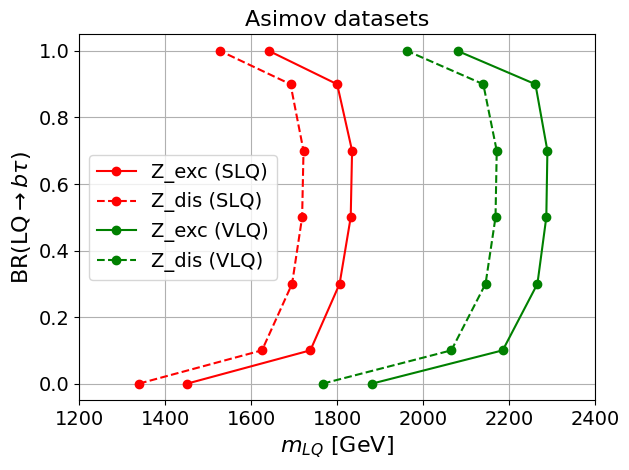

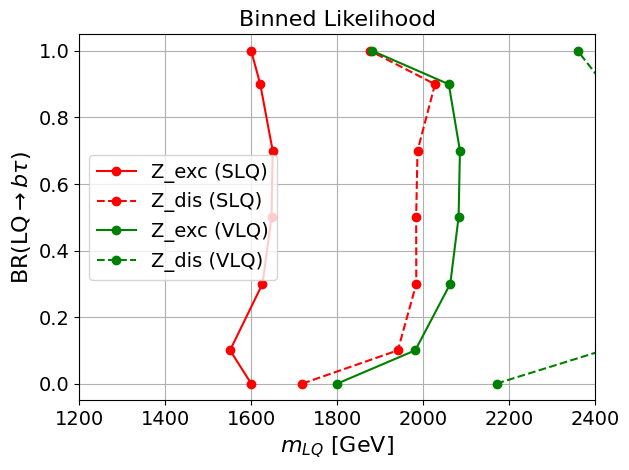

In [80]:
# plot ASIMOV DATASETS

plt.plot(m_asimov_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_asimov_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_asimov_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_asimov_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Asimov datasets', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ)')

plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ)')

plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [81]:

# SAVE

file_path = mainfolder + 'saved-results/Z14TeV_err_up_Z3.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    betas,
    m_asimov_exc_SLQ_14TeV,
    m_asimov_dis_SLQ_14TeV,
    m_asimov_exc_VLQ_14TeV,
    m_asimov_dis_VLQ_14TeV,
    m_BL_exc_SLQ_14TeV,
    m_BL_dis_SLQ_14TeV,
    m_BL_exc_VLQ_14TeV,
    m_BL_dis_VLQ_14TeV,
    m_BL_exc_SLQ_low_14TeV,
    m_BL_dis_SLQ_low_14TeV,
    m_BL_exc_VLQ_low_14TeV,
    m_BL_dis_VLQ_low_14TeV,
    m_BL_exc_SLQ_high_14TeV,
    m_BL_dis_SLQ_high_14TeV,
    m_BL_exc_VLQ_high_14TeV,
    m_BL_dis_VLQ_high_14TeV
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# betas m_asimov_exc_SLQ_14TeV m_asimov_dis_SLQ_14TeV m_asimov_exc_VLQ_14TeV m_asimov_dis_VLQ_14TeV m_BL_exc_SLQ_14TeV m_BL_dis_SLQ_14TeV m_BL_exc_VLQ_14TeV m_BL_dis_VLQ_14TeV m_BL_exc_SLQ_low_14TeV m_BL_dis_SLQ_low_14TeV m_BL_exc_VLQ_low_14TeV m_BL_dis_VLQ_low_14TeV m_BL_exc_SLQ_high_14TeV m_BL_dis_SLQ_high_14TeV m_BL_exc_VLQ_high_14TeV m_BL_dis_VLQ_high_14TeV',
           comments='')

print(f"Data saved to: {file_path}")


Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/Z14TeV_err_up_Z3.txt


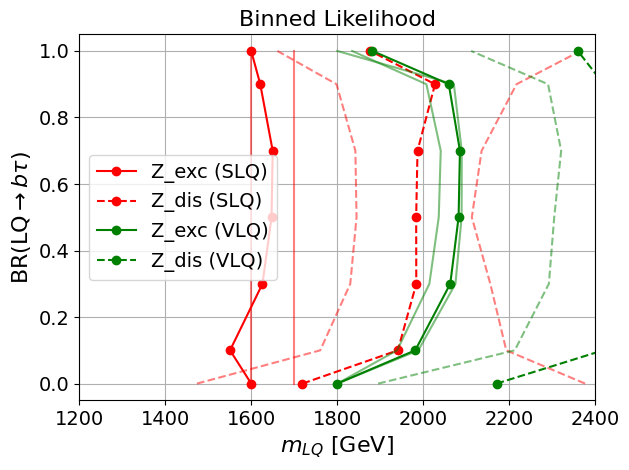

In [82]:

# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_up_Z3.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV_up = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV_up = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV_up = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV_up = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV_up = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV_up = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV_up = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV_up = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV_up = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV_up = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV_up = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV_up = loaded_data[:, 16]





# plot BINNED LIKEHOOD

plt.plot(m_BL_exc_SLQ_14TeV_up, betas, 'o-', c='red', label='Z_exc (SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV_up, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV_up, betas, 'o--', c='red', label='Z_dis (SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV_up, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV_up, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_VLQ_14TeV_up, betas, 'o-', c='green', label='Z_exc (VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV_up, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV_up, betas, 'o--', c='green', label='Z_dis (VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV_up, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV_up, betas, '--', c='green', alpha=0.5)

# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

#### no sistematics

In [25]:

# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err_Z3.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]


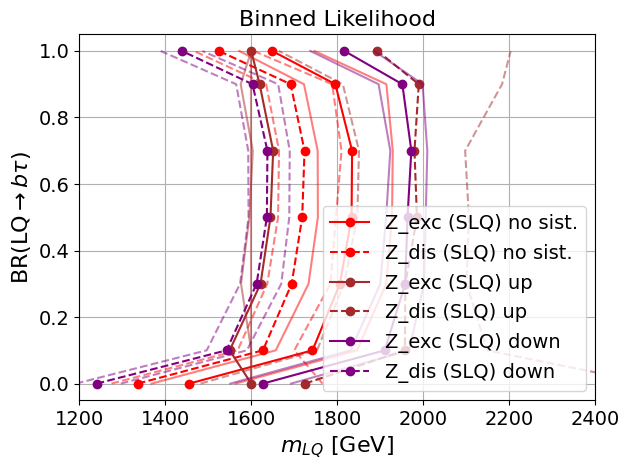

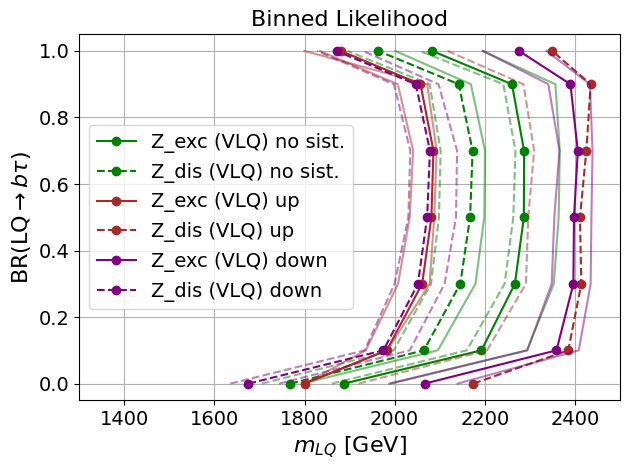

In [26]:
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o-', c='red', label='Z_exc (SLQ) no sist.')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o--', c='red', label='Z_dis (SLQ) no sist.')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '--', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '--', c='red', alpha=0.5)

plt.plot(m_BL_exc_SLQ_14TeV_up, betas, 'o-', c='brown', label='Z_exc (SLQ) up')
plt.plot(m_BL_exc_SLQ_low_14TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV_up, betas, 'o--', c='brown', label='Z_dis (SLQ) up')
plt.plot(m_BL_dis_SLQ_low_14TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_SLQ_14TeV_down, betas, 'o-', c='purple', label='Z_exc (SLQ) down')
plt.plot(m_BL_exc_SLQ_low_14TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_14TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV_down, betas, 'o--', c='purple', label='Z_dis (SLQ) down')
plt.plot(m_BL_dis_SLQ_low_14TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV_down, betas, '--', c='purple', alpha=0.5)



# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1200,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()



plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o-', c='green', label='Z_exc (VLQ) no sist.')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o--', c='green', label='Z_dis (VLQ) no sist.')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '--', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '--', c='green', alpha=0.5)

plt.plot(m_BL_exc_VLQ_14TeV_up, betas, 'o-', c='brown', label='Z_exc (VLQ) up')
plt.plot(m_BL_exc_VLQ_low_14TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV_up, betas, '-', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV_up, betas, 'o--', c='brown', label='Z_dis (VLQ) up')
plt.plot(m_BL_dis_VLQ_low_14TeV_up, betas, '--', c='brown', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV_up, betas, '--', c='brown', alpha=0.5)

plt.plot(m_BL_exc_VLQ_14TeV_down, betas, 'o-', c='purple', label='Z_exc (VLQ) down')
plt.plot(m_BL_exc_VLQ_low_14TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_14TeV_down, betas, '-', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV_down, betas, 'o--', c='purple', label='Z_dis (VLQ) down')
plt.plot(m_BL_dis_VLQ_low_14TeV_down, betas, '--', c='purple', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV_down, betas, '--', c='purple', alpha=0.5)


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1300,2500)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()